## Imports & Config

In [1]:
import os, random
import numpy as np
import tensorflow as tf
from keras.applications import ResNet50
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE= 0.0001
IMG_SIZE = 224
DROPOUT_RATE = 0.3

PROCESSED_DIR = '../data/processed'
SPLITS_DIR = '../data/splits'
SAVED_MODELS_DIR = '../saved_models'
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)


## Load Data

In [2]:
X_img = np.load(os.path.join(PROCESSED_DIR, 'X_img.npy'), mmap_mode='r')
y_match = np.load(os.path.join(PROCESSED_DIR, 'y_match.npy'))

idx_train = np.load(os.path.join(SPLITS_DIR, 'idx_train.npy'))
idx_val = np.load(os.path.join(SPLITS_DIR, 'idx_val.npy'))
idx_test = np.load(os.path.join(SPLITS_DIR, 'idx_test.npy'))

print(f"X_img shape: {X_img.shape}")
print(f"y_match shape: {y_match.shape}")


X_img shape: (15000, 224, 224, 3)
y_match shape: (15000,)


## Data Preparation

In [3]:
from keras.utils import Sequence
import math

# Use y_match_cat for generator
y_match_cat = y_match.astype(np.int32)

class DataGenerator(Sequence):
    def __init__(self, X, y, indices, batch_size, shuffle=True):
        self.X = X
        self.y = y
        self.indices = indices
        self.batch_size = batch_size
        self.shuffle = shuffle
        super().__init__()
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)

    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        X_batch = self.X[batch_idx].astype(np.float32)
        y_batch = self.y[batch_idx]
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = DataGenerator(X_img, y_match.astype(np.int32), idx_train, BATCH_SIZE, shuffle=True)
val_gen = DataGenerator(X_img, y_match.astype(np.int32), idx_val, BATCH_SIZE, shuffle=False)
test_gen = DataGenerator(X_img, y_match.astype(np.int32), idx_test, BATCH_SIZE, shuffle=False)


## Label Creation

In [4]:
# Labels are now handled inside the DataGenerator directly using y_match_cat.
# We extract y_true directly from the test indices for evaluation purposes.
y_true = y_match[idx_test]


## Train/Val/Test Split

In [5]:
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")


Train: 10500, Val: 2250, Test: 2250


## Build Model
**M1 CNN: Why ResNet-50?**
- Chosen: ResNet-50 pretrained on ImageNet — transfer learning from 1M+ images
- **MobileNet**: MobileNet is optimized for mobile/edge deployment with fewer parameters. Our task prioritizes accuracy over speed, making ResNet-50's deeper feature hierarchy more appropriate.
- **EfficientNet**: EfficientNet-B0/B4 is a strong alternative and could be tested in ablation. ResNet-50 was chosen for its well-documented behavior on transfer learning tasks and simpler fine-tuning setup.
- **ViT**: Vision Transformers require large datasets (100K+ images) to outperform CNNs. With 15000 unique game covers, a pretrained CNN with fine-tuning is more reliable. ViT is noted as future work.


In [6]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Freeze base

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
extractor_output = Dense(256, activation='relu', name='extractor_output')(x)
x = Dropout(DROPOUT_RATE)(extractor_output)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extractor_output (Dense)        │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Compile Model

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [8]:
from sklearn.utils.class_weight import compute_class_weight
cw_array = compute_class_weight('balanced', classes=np.unique(y_match[idx_train]), y=y_match[idx_train])
cw = {0: cw_array[0], 1: cw_array[1]}

from keras.callbacks import EarlyStopping, ModelCheckpoint
import os
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(os.path.join(SAVED_MODELS_DIR, 'M1_best.keras'), save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=cw,
    callbacks=callbacks
)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1000s 6s/step - accuracy: 0.5229 - loss: 0.7234 - val_accuracy: 0.5973 - val_loss: 0.6897
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 965s 6s/step - accuracy: 0.5793 - loss: 0.6957 - val_accuracy: 0.6093 - val_loss: 0.6787
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 963s 6s/step - accuracy: 0.6074 - loss: 0.6775 - val_accuracy: 0.8191 - val_loss: 0.6181
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 866s 5s/step - accuracy: 0.6255 - loss: 0.6709 - val_accuracy: 0.8520 - val_loss: 0.5346
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 862s 5s/step - accuracy: 0.6457 - loss: 0.6684 - val_accuracy: 0.8520 - val_loss: 0.5297
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 851s 5s/step - accuracy: 0.6557 - loss: 0.6719 - val_accuracy: 0.7258 - val_loss: 0.6756
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 842s 5s/step - accuracy: 0.6495 - loss: 0.6688 - val_accuracy: 0.7138 - val_loss: 0.6848
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 855s 5s/step - accuracy: 0.6896 - loss: 0.6660 - val_acc

## Training Curves

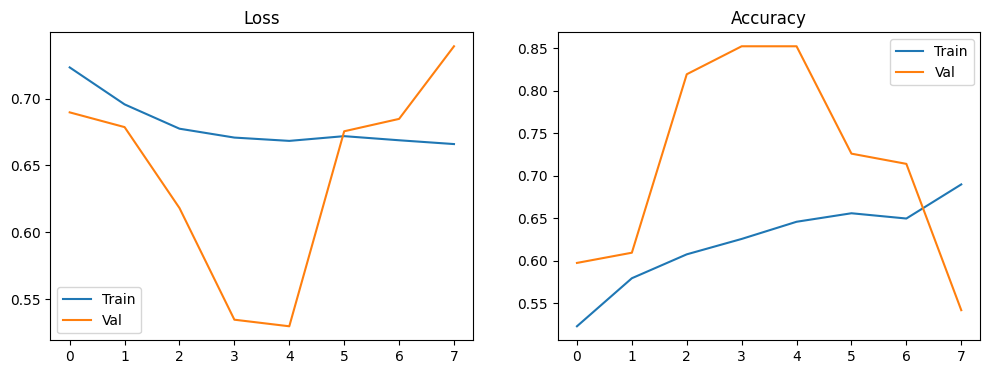

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()


## Evaluate on Test Set

In [10]:
model.evaluate(test_gen)
y_pred_proba = model.predict(test_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_true, y_pred))


36/36 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.8658 - loss: 0.5220
36/36 ━━━━━━━━━━━━━━━━━━━━ 150s 4s/step
              precision    recall  f1-score   support

           0       0.90      0.95      0.93      1981
           1       0.39      0.22      0.28       269

    accuracy                           0.87      2250
   macro avg       0.64      0.58      0.60      2250
weighted avg       0.84      0.87      0.85      2250



## Confusion Matrix

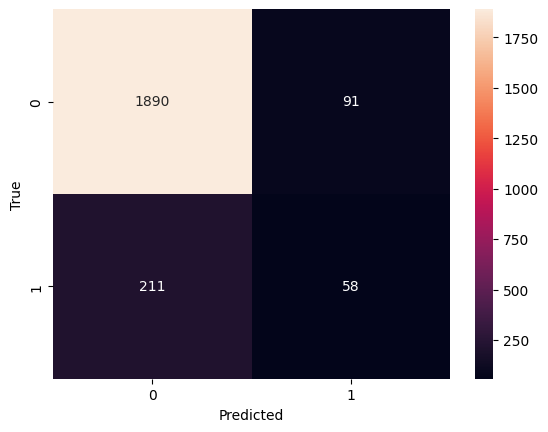

In [11]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## Error Analysis
- **Common Failure Pattern**: Game covers that look similar across genres (e.g. dark fantasy vs horror).
- **Likely Cause**: ResNet-50 visual features don't separate genre-adjacent styles.
- **Potential Fix**: Fine-tune more layers or use genre metadata as auxiliary input.

In [12]:
# Step 1 — Find misclassified samples
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

label_names = ["No Match", "Match"]

sample_errors = wrong_idx[:5]
for i in sample_errors:
    print(f"\n--- Sample {i} ---")
    print(f"True label: {label_names[y_true[i]]}")
    print(f"Predicted label: {label_names[y_pred[i]]}")
    print(f"Confidence: {y_pred_proba[i][y_pred[i]]*100:.1f}%")

# Step 2 — Error breakdown by class
for i, cls in enumerate(label_names[:min(len(label_names), cm.shape[0])]):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    if total > 0:
        print(f"{cls}: FP={fp}, FN={fn}, FNR={fn/total*100:.1f}% (missed), FPR={fp/max(1, (cm.sum()-total))*100:.1f}% (false alarms)")



Total misclassified: 302 / 2250 (13.4%)

--- Sample 7 ---
True label: Match
Predicted label: No Match
Confidence: 73.3%

--- Sample 13 ---
True label: Match
Predicted label: No Match
Confidence: 73.3%

--- Sample 15 ---
True label: Match
Predicted label: No Match
Confidence: 58.4%

--- Sample 20 ---
True label: Match
Predicted label: No Match
Confidence: 58.4%

--- Sample 21 ---
True label: Match
Predicted label: No Match
Confidence: 63.9%
No Match: FP=211, FN=91, FNR=4.6% (missed), FPR=78.4% (false alarms)
Match: FP=91, FN=211, FNR=78.4% (missed), FPR=4.6% (false alarms)


## Save Extractor

In [13]:
extractor = Model(inputs=model.input, outputs=model.get_layer('extractor_output').output)
extractor.save(os.path.join(SAVED_MODELS_DIR, 'M1_extractor.keras'))
